```
1. Przygotwać wizualizację progowania w regresji logistycznej
2. Przećwiczyć confusion matrix - budowanie/ regresje logistyczna itp.
3. Przeliczenie ręczne pojedynczego drzewa decyzyjnego - na podstawie rysunku drzewa przeliczyć dwie lub trzy alternatywy ręcznie na tablicy/papierze, żeby całkowite G_{after} policzyć i zobaczyć, że ciepło ma najmniejszą nieczystość.
4. Pokazać na ćwiczeniach może przejście z drzew klasyfikujących binarne wartośći do progowania, a potem drzewa regresyjnego - to powinno naturalnie po wykładzie się udać i dość szybko.
5. Boosting/XGBoost? - zastanowić się jak to przedstawić i czy od razu na ćwiczeniach? Może tylko wykład ostatni pierwsza 1-2 godziny
6. Co nam jeszcze zostało? - LDA,QDA, KNN, PCA - W sumie to można dość szybko opowiedzieć. SVM - też  powinno się dać, bo mamy już intuicję z geogebry i często opowiadałem o tym. 
7. Pytanie co z manifold learning? :) Przydałaby się jeszcze przynajmniej godzina na to, ewentualnie wspomnieć na wykładzie i na ostatnich ćwiczeniach zrobić z tego ćwiczenie.

```

# 01. Pierwsze drzewo decyzyjne: kupić lody?

Cel: zbudować pierwsze drzewo **ręcznie**, a dopiero potem porównać je z `DecisionTreeClassifier`.

Przykład jest celowo mały. Każdy wiersz to jedna sytuacja, a celem jest decyzja `kup_lody`.

Legenda cech:

| cecha | 1 oznacza | 0 oznacza |
|---|---|---|
| `cieplo` | jest ciepło | nie jest ciepło |
| `weekend` | jest weekend | dzień powszedni |
| `krotka_kolejka` | kolejka jest krótka | kolejka jest długa |

Po zajęciach student powinien umieć odpowiedzieć:

1. Co oznacza „nieczystość” w węźle drzewa?
2. Jak wybrać pierwszy podział?
3. Jak zamienić drzewo na proste reguły `if/else`?

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Szukamy pliku CSV w katalogu projektu.
# Dzięki temu notebook działa zarówno z katalogu głównego projektu,
# jak i z podkatalogu, np. notebooks/.
BASE = Path.cwd()
if not (BASE / "data").exists():
    BASE = BASE.parent

csv_path = BASE / "data" / "01_lody.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    # Fallback dydaktyczny: gdy notebook jest uruchamiany bez katalogu data/,
    # tworzymy mały zbiór danych bezpośrednio w notebooku.
    df = pd.DataFrame({
        "id": list(range(1, 15)),
        "cieplo": [0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1],
        "weekend": [0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0],
        "krotka_kolejka": [0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1],
        "kup_lody": ["nie", "nie", "nie", "nie", "nie", "tak", "tak", "tak",
                      "tak", "nie", "tak", "nie", "tak", "tak"]
    })

df

,id,cieplo,weekend,krotka_kolejka,kup_lody
0,1,0,0,0,nie
1,2,0,0,1,nie
2,3,0,1,0,nie
3,4,0,1,1,nie
4,5,1,0,0,nie
5,6,1,0,1,tak
6,7,1,1,0,tak
7,8,1,1,1,tak
8,9,1,0,1,tak
9,10,0,1,1,nie


In [5]:
df["kup_lody"].value_counts(normalize=True)

nie    0.5
tak    0.5
Name: kup_lody, dtype: float64

## 2. Nieczystość Giniego

Dla klasyfikacji często używa się miary Giniego:

$$Gini = 1 - \sum_k p_k^2$$

Jeżeli w węźle są same przykłady jednej klasy, Gini = 0. Jeżeli klasy są wymieszane pół na pół, Gini jest większe.

było zimno 4/5 osob nie kupiło lodów
1 /5 kupiła 
Gini = 1 - ( (4/5)^2 + (1/5)^2) = 1 - 16/25 - 1/25 = 1 - 17/25 = 8/25 = 0.32

In [ ]:
Samples = 4
G = 1 - (2/4)^2 - (2/4)^2 = 1 - (1/2)^2 - (1/2)^2 = 0.5

## Gini impurity i zysk Giniego

W drzewach decyzyjnych chcemy tworzyć podziały danych (splity), które jak najlepiej rozdzielają klasy.

Do mierzenia „chaosu” klas używa się m.in. **Gini impurity**.

Dla problemu binarnego:

$$
G = 1 - p_0^2 - p_1^2
$$

gdzie:
- $p_0$ — prawdopodobieństwo klasy 0,
- $p_1$ — prawdopodobieństwo klasy 1.

Można też zapisać:

$$
G = 2p(1-p)
$$

gdzie:
- $p$ oznacza prawdopodobieństwo jednej z klas.

---

### Interpretacja

- $G=0$ → dane są idealnie czyste (same 0 lub same 1),
- $G=0.5$ → maksymalny chaos dla dwóch klas (50% / 50%).

Im bardziej klasy są wymieszane, tym większa wartość Gini impurity.

---

### Zysk Giniego (Gini gain)

Drzewo decyzyjne sprawdza, jak bardzo split zmniejsza chaos klas.

Najpierw liczymy impurity przed podziałem:

$$
G_{\text{before}}
$$

Następnie impurity po podziale:

$$
G_{\text{after}}
=
\frac{N_L}{N}G_L
+
\frac{N_R}{N}G_R
$$

gdzie:
- $N_L$, $N_R$ — liczba elementów po lewej i prawej stronie splitu,
- $G_L$, $G_R$ — impurity dla obu grup.

Zysk Giniego:

$$
\text{Gini Gain}
=
G_{\text{before}}
-
G_{\text{after}}
$$

Im większy zysk Giniego:
- tym lepszy split,
- tym lepiej dane zostały uporządkowane przez drzewo.

---

### Intuicja

Drzewo decyzyjne szuka pytań typu:

> „Czy ta cecha pozwala lepiej oddzielić klasy?”

Dobry split:
- zmniejsza chaos,
- zwiększa czystość grup,
- prowadzi do bardziej jednoznacznych decyzji klasyfikacyjnych.

In [ ]:
G_after = 5/14 * 0.0 + 9/14 * 0.346 = 0.222428

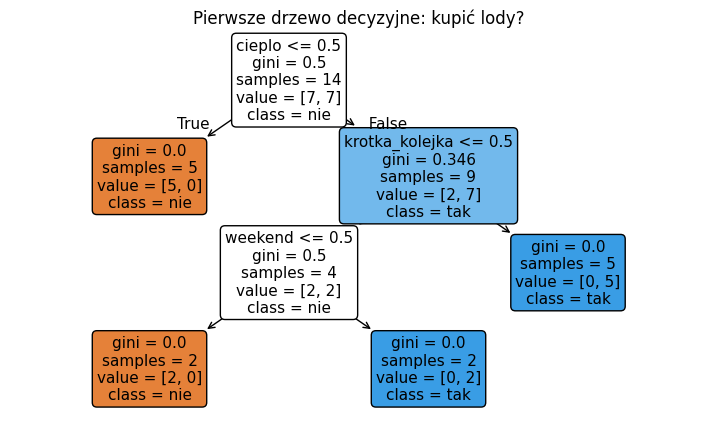

$$
G_{\text{after}}
=
\frac{N_L}{N}G_L
+
\frac{N_R}{N}G_R
$$

$$
G = 1 - p_0^2 - p_1^2
$$


```
Sytuacja wyimaginowana, że w zimnym dniu są osoby (jedna osoba na pięć), które kupiły lody:
było zimno 4/5 osob nie kupiło lodów
1 /5 kupiła 
Gini = 1 - ( (4/5)^2 + (1/5)^2) = 1 - 16/25 - 1/25 = 1 - 17/25 = 8/25 = 0.32
```

Samples = 4
G = 1 - (2/4)^2 - (2/4)^2 = 1 - (1/2)^2 - (1/2)^2 = 0.5

# Mini-ćwiczenie
```
Dla ciepłego dnia w pierwszym poziomie drzewa (ciepło jako główny/pierwszy krok decyzyjny) policzyć nieczystość Giniego - dla tego liścia/gałęzi.
Gini = 1 - (2/9)^2 - (7/9)^2 = 1 - 4/81 - 49/81 = 28/81 = 0.346
```

9/14*0.346 = 

In [8]:
def gini(labels):
    probs = labels.value_counts(normalize=True)
    return 1 - np.sum(probs**2)
parent_gini = gini(df["kup_lody"])
parent_gini

0.5

In [9]:
def split_score(data, feature, target="kup_lody"):
    rows = []
    weighted_gini = 0
    n_total = len(data)
    
    for value,part in data.groupby(feature):
        part_gini = gini(part[target])
        weight = len(part)/n_total
        weighted_gini += weight*part_gini
        rows.append({
            "cecha": feature,
            "wartosc": value,
            "liczba_wierszy": len(part),
            "klasy": dict(part[target].value_counts()),
            "gini_dziecka": round(part_gini, 3),
            "waga": round(weight, 3)
        })
        
    return weighted_gini,pd.DataFrame(rows)
scores = []
for feature in ["cieplo", "weekend", "krotka_kolejka"]:
    score, details = split_score(df, feature)
    scores.append({"cecha": feature, "gini_po_podziale": score, "zysk_gini": parent_gini - score})

pd.DataFrame(scores).sort_values("gini_po_podziale")

,cecha,gini_po_podziale,zysk_gini
0,cieplo,0.222222,0.277778
2,krotka_kolejka,0.458333,0.041667
1,weekend,0.489796,0.010204


In [10]:
score, details = split_score(df,"cieplo")
details

,cecha,wartosc,liczba_wierszy,klasy,gini_dziecka,waga
0,cieplo,0,5,{'nie': 5},0.000,0.357
1,cieplo,1,9,"{'tak': 7, 'nie': 2}",0.346,0.643


In [12]:
print(9/14)

0.6428571428571429


In [14]:
warm = df[df["cieplo"]==1]
warm

,id,cieplo,weekend,krotka_kolejka,kup_lody
4,5,1,0,0,nie
5,6,1,0,1,tak
6,7,1,1,0,tak
7,8,1,1,1,tak
8,9,1,0,1,tak
10,11,1,1,0,tak
11,12,1,0,0,nie
12,13,1,1,1,tak
13,14,1,0,1,tak


In [17]:
scores_warm = []
for feature in ["weekend","krotka_kolejka"]:
    score, _ = split_score(warm,feature)
    scores_warm.append({"cecha": feature, 
                        "gini_po_podziale": score, 
                        "zysk_gini": gini(warm["kup_lody"]) - score})

pd.DataFrame(scores_warm).sort_values("gini_po_podziale")

,cecha,gini_po_podziale,zysk_gini
1,krotka_kolejka,0.222222,0.123457
0,weekend,0.266667,0.079012


DecissionTreeClassifier(...)



In [20]:
X = df[["cieplo","weekend","krotka_kolejka"]]
y = df["kup_lody"]

tree = DecisionTreeClassifier(criterion="gini",max_depth=3, random_state=42)
tree.fit(X,y)
print(export_text(tree,feature_names=list(X.columns)))

|--- cieplo <= 0.50
|   |--- class: nie
|--- cieplo >  0.50
|   |--- krotka_kolejka <= 0.50
|   |   |--- weekend <= 0.50
|   |   |   |--- class: nie
|   |   |--- weekend >  0.50
|   |   |   |--- class: tak
|   |--- krotka_kolejka >  0.50
|   |   |--- class: tak



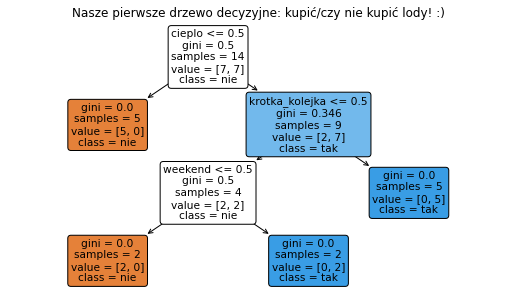

In [25]:
plt.figure(figsize=(9,5))
plot_tree(
    tree,
    feature_names=list(X.columns),
    class_names= list(tree.classes_),
    filled=True,
    rounded=True,
    impurity=True
)
plt.title("Nasze pierwsze drzewo decyzyjne: kupić/czy nie kupić lody! :)")
plt.show()